# Paper Figure 4: STARR-seq Analysis Pipeline

This notebook documents the comprehensive workflow for analyzing STARR-seq data to generate **Figure 4**.
The pipeline consists of the following key steps:

1.  **Quality Control**: Filtering and trimming raw sequencing reads using Trimmomatic.
2.  **Read Alignment**: Mapping reads to reference promoter sequences using Bowtie2.
3.  **Plasmid Library Processing**: Establishing barcode-promoter correspondence and counting Input reads.
4.  **cDNA Library Processing**: Counting Output reads from cDNA sequencing.
5.  **Enrichment Calculation**: Computing promoter activity scores (Enrichment) based on Input/Output ratios.
6.  **Result Aggregation and Model Prediction**: integrating replicates, mapping sequences, and predicting activity using TargetGAN.
7.  **Visualization of Results**: Generating the correlation plots and activity comparisons shown in Figure 4.

## 1. Quality Control
Use **Trimmomatic** to filter out low-quality reads and trim adapters from the raw sequencing data.


In [ ]:
!java -jar ./trimmomatic-0.39.jar PE -threads 50 ./SPO-P1R1-0120_raw_1.fq.gz ./SPO-P1R1-0120_raw_2.fq.gz ./SPO-P1R1-0120_1_trim_paired.fq.gz ./SPO-P1R1-0120_1_trim_unpaired.fq.gz ./SPO-P1R1-0120_2_trim_paired.fq.gz ./SPO-P1R1-0120_2_trim_unpaired.fq.gz ./TruSeq3-PE.fa:2:30:10 LEADING:3 TRAILING:3 SLIDINGWINDOW:4:15 MINLEN:30

## 2. Read Alignment
Align the trimmed paired-end reads to the original reference sequences using **Bowtie2**.


### 2.1 Build Reference Index
Construct a Bowtie2 index for the known promoter sequences (`pro.fa`).


In [ ]:
!bowtie2-build ./data_for_plot/pro.fa ./data_for_plot/pro_index/pro


### 2.2 Align Reads
Perform the alignment to generate a SAM file containing the mapping results.


In [ ]:
!bowtie2 -p 20 --xeq --no-unal -x pro_index/pro -1 ./SPO-P1R2-0120_1_trim_paired.fq.gz -2 ./SPO-P1R2-0120_2_trim_paired.fq.gz -S pro.sam

### 2.3 Extract Alignment Information
Processes the SAM file to extract key information (Read ID, Gene, Position, CIGAR, Sequence) into a TSV format using `bioawk`.


In [ ]:
!cat pro.sam | bioawk -c sam -t 'BEGIN{print "read", "gene", "start", "cigar", "sequence"} {sub(/:[ACGTN+]*;.*$/, "", $qname); print $qname, $rname, $pos, $cigar, $seq}' > pro.tsv

## 3. Plasmid Library Processing
Run `plasmid_process.py` to:
1. Establish the correspondence between promoter sequences and barcodes.
2. Count the number of reads in the **Input** library.


In [ ]:
!python plasmid_process.py

## 4. cDNA Library Processing
Run `cdna_process.py` to:
1. Process the cDNA sequencing results.
2. Generate `cdna.text` containing the **Output** read counts.


In [ ]:
!python cdna_process.py

## 5. Calculate Enrichment Scores from STARR-seq Data
Perform enrichment analysis for 3 biological replicates. The process involves:
1.  **Data Loading**: Reading cDNA (Output) and Barcode-Promoter (Input) mapping files.
2.  **Filtering**: Removing barcodes that map to multiple promoters to ensure specificity.
3.  **Enrichment Calculation**: Computing sequences' activity using the log-ratio of Output/Input frequencies.
4.  **Normalization**: Adjusting scores relative to the internal control (35S promoter).
5.  **Aggregation**: Summarizing enrichment scores at the gene level.

In [96]:
import warnings
import pandas as pd
import numpy as np
from collections import Counter
from utils import reversed_seq, get_median_row

# Suppress warnings for cleaner output
warnings.simplefilter(action='ignore', category=FutureWarning)

# Define data path
result_path = '/dev_16T1/xlxiang/xxl_desktop/xlxiang/last_TargetGAN/figplot_code/STARR-seq/result/first-experimental'
result_df = {}

print("Starting Enrichment Calculation for 3 Replicates...")

for i in range(3):
    replicate_id = i + 1
    
    # ---------------------------------------------------------
    # 1. Process cDNA (Output) Library
    # ---------------------------------------------------------
    cdna_file = f'{result_path}/cdna_repeat{replicate_id}.txt'
    cdna = pd.read_csv(cdna_file)
    # Count frequency of each barcode in cDNA library
    counter = Counter(cdna['rever_bar'])
    df_cdna = pd.DataFrame(counter.items(), columns=['reversed_bar', 'output'])
    
    # ---------------------------------------------------------
    # 2. Process Plasmid (Input) Library
    # ---------------------------------------------------------
    bar_pro_file = f'{result_path}/bar_pro_repeat{replicate_id}.txt'
    bar_pro = pd.read_csv(bar_pro_file, index_col=0)
    # Generate reverse complement for barcodes to match cDNA sequencing direction
    bar_pro['reversed_bar'] = reversed_seq(list(bar_pro['bar']))
    
    # ---------------------------------------------------------
    # 3. Filter Promiscuous Barcodes
    # ---------------------------------------------------------
    # Identify barcodes mapping to a single promoter
    barcode_gene_counts = bar_pro.groupby('reversed_bar')['gene'].nunique().reset_index(name='num_pro')
    unique_mapping_barcodes = barcode_gene_counts[barcode_gene_counts['num_pro'] == 1]['reversed_bar']
    
    # Calculate and print specificity stats
    specificity_ratio = len(unique_mapping_barcodes) / bar_pro['reversed_bar'].nunique()
    print(f"Repeat {replicate_id}: {specificity_ratio:.2%} of barcodes map to a unique promoter.")
    
    # Keep only uniquely mapped barcodes
    valid_bar_pro = bar_pro[bar_pro['reversed_bar'].isin(unique_mapping_barcodes)]
    
    # Count frequency in Input library
    result_input = valid_bar_pro.groupby(['gene', 'reversed_bar']).size().reset_index(name='input')
    
    # ---------------------------------------------------------
    # 4. Calculate Enrichment
    # ---------------------------------------------------------
    # Merge Input and Output data
    result = result_input.merge(df_cdna, on='reversed_bar', how='inner')
    
    # Compute RPM (Reads Per Million) like normalization ratios
    total_input = result['input'].sum()
    total_output = result['output'].sum()
    
    # Enrichment = log2( (Output/Total_Output) / (Input/Total_Input) )
    result['enrichment'] = np.log2(
        (result['output'] / total_output) / 
        (result['input'] / total_input)
    )
    
    # Normalize to '35S' promoter baseline
    baseline_val = result.loc[result['gene'] == '35s', 'enrichment'].values[0]
    result['enrichment'] = result['enrichment'] - baseline_val
    
    # ---------------------------------------------------------
    # 5. Aggregate per Gene
    # ---------------------------------------------------------
    # For genes with multiple barcodes, select the median enrichment or specific row via utils
    result_with_median_row = result.groupby('gene', group_keys=False).apply(get_median_row)
    
    # Calculate final median enrichment per gene
    gene_enrichment = result.groupby('gene').apply(
        lambda x: x['enrichment'].median() if x['reversed_bar'].nunique() > 1 else x['enrichment'].iloc[0]
    ).reset_index(name='enrichment_median')
    
    result_df[i] = gene_enrichment
    print(f"---------------- Replicate {replicate_id} Processed ----------------")

print("All replicates processed successfully.")

Starting Enrichment Calculation for 3 Replicates...
Repeat 1: 89.53% of barcodes map to a unique promoter.
---------------- Replicate 1 Processed ----------------
Repeat 2: 89.52% of barcodes map to a unique promoter.
---------------- Replicate 2 Processed ----------------
Repeat 3: 85.21% of barcodes map to a unique promoter.
---------------- Replicate 3 Processed ----------------
All replicates processed successfully.


## 6. Result Aggregation and Model Prediction
Integrate results from all replicates to:
1.  **Merge Data**: Combine enrichment scores from the three replicates.
2.  **Statistical Analysis**: Calculate the average activity and Coefficient of Variation (CV).
3.  **Sequence Mapping**: Retrieve the corresponding DNA sequences for each gene.
4.  **Model Prediction**: Use the trained `TargetGAN` predictor to estimate activity.
5.  **Quality Filtering**: Exclude data points with high variability (CV > 30%).

In [114]:
import tensorflow as tf
from utils import one_hot_encode

# ---------------------------------------------------------
# 1. Merge Replicates
# ---------------------------------------------------------
# Merge the three result dataframes on 'gene'
last_df = result_df[0].merge(result_df[1], on='gene').merge(result_df[2], on='gene')

# Rename columns for clarity
col_mapping = {
    'enrichment_median_x': 'log2(experimental activity, repetition 1)',
    'enrichment_median_y': 'log2(experimental activity, repetition 2)',
    'enrichment_median': 'log2(experimental activity, repetition 3)'
}
last_df = last_df.rename(columns=col_mapping)

# ---------------------------------------------------------
# 2. Calculate Statistics
# ---------------------------------------------------------
activity_cols = list(col_mapping.values())

# Calculate Average (on log2 scale)
last_df['log2(activity_avg)'] = last_df[activity_cols].mean(axis=1)
last_df['CV (%)'] = np.abs(last_df[activity_cols].std(axis=1) / last_df[activity_cols].mean(axis=1)) * 100

# Remove the first row if it contains artifacts/headers (based on previous logic)
last_df = last_df.iloc[1:, :]

# ---------------------------------------------------------
# 3. Map Sequences
# ---------------------------------------------------------
mapping_file = './data_for_plot/sequence_to_name_mapping.xlsx'
seq_mapping = pd.read_excel(mapping_file)

# Merge with sequence mapping
last_df = last_df.merge(seq_mapping, left_on='gene', right_on='name2')

# Clean up columns: convert name2/sequence duplicates
if 'sequence_x' in last_df.columns and 'sequence_y' in last_df.columns:
    last_df['sequence'] = last_df['sequence_x']
    last_df = last_df.drop(columns=['sequence_x', 'sequence_y'])

cols_to_drop = [c for c in ['name2', 'name2_x', 'name2_y'] if c in last_df.columns]
last_df = last_df.drop(columns=cols_to_drop, errors='ignore')

# ---------------------------------------------------------
# 4. Predict Activity with TargetGAN
# ---------------------------------------------------------
model_path = '../data/predictor.h5'
print(f"Loading model from {model_path}...")
model = tf.keras.models.load_model(model_path)

# One-hot encode sequences for prediction
input_seqs = np.array([one_hot_encode(seq) for seq in last_df['sequence'].tolist()])
print(f"Predicting activity for {len(input_seqs)} sequences...")
predictions = model.predict(input_seqs, batch_size=512, verbose=0)

last_df['log2(predicted_activity)'] = predictions

# ---------------------------------------------------------
# 5. Filter & Save
# ---------------------------------------------------------
# Filter out high variance data points (CV > 30%)
initial_count = len(last_df)
last_df = last_df[last_df['CV (%)'] <= 30]
filtered_count = len(last_df)
print(f"Filtered {initial_count - filtered_count} sequences with CV > 30%. Remaining: {filtered_count}")

# Save to Excel
output_file = './data_for_plot/starr_seq_result.xlsx'
last_df.set_index('name1', inplace=True)
last_df.to_excel(output_file, index=True)
print(f"Results saved to {output_file}")

# Display first few rows
last_df.head()

Loading model from ../data/predictor.h5...
Predicting activity for 4510 sequences...
Filtered 930 sequences with CV > 30%. Remaining: 3580
Results saved to ./data_for_plot/starr_seq_result.xlsx


,gene,"log2(experimental activity, repetition 1)","log2(experimental activity, repetition 2)","log2(experimental activity, repetition 3)",log2(activity_avg),CV (%),sequence,log2(predicted_activity)
name1,,,,,,,,
NP750,Actin,2.522596,2.094205,2.254300,2.290367,9.450932,CCAGTCCCCACGGCCGTCACGCTCGCAGCACCGGCCGTTTTCTACG...,-1.255382
NP93,ENSRNA049469069,2.393902,3.611702,3.143104,3.049570,20.142665,CTAGCTCCAGCTTCCAGCCATGCCTCACCCCTCATGGCATGGCTGG...,-0.398657
NP666,ENSRNA049481266,2.393902,2.261205,2.277020,2.310709,3.136691,ACACACCCCTCTATAAACCCCTCATGCCATCTGCCTTCTTCATTCA...,-1.171234
NP555,ENSRNA049481968,2.300793,1.939277,2.416245,2.218772,11.215111,GGCCCCCCTGTCATCCGCTGCTACGCCAATGCAATGTCCTACAGTA...,-1.188979
NP471,ENSRNA049483182,1.602828,2.524240,2.970507,2.365858,29.480191,AAGAACCACGTACAATGCTCACAGGGGCGGCGTCAGCTAGCTAGCT...,-1.585087


## 7. Visualization of Results

In [123]:
SPs_df = last_df[last_df.index.str.startswith('SP')]
SPs_df.head()

,gene,"log2(experimental activity, repetition 1)","log2(experimental activity, repetition 2)","log2(experimental activity, repetition 3)",log2(activity_avg),CV (%),sequence,log2(predicted_activity)
name1,,,,,,,,
SP1008,PP-1008F,4.300793,4.797258,5.460668,4.852906,11.991507,CCACACCCCGGGGTCTATAAAACCCGCCACGCGAACCCACCCTCCA...,3.992136
SP100,PP-100F,4.393902,3.846168,3.031908,3.757326,18.239825,CTACCCCCTCCTGATCGATCCTCGCCTATAAATACCCCTCGCCCCC...,5.142095
SP1018,PP-1018F,2.201257,3.398709,3.090801,2.896922,21.464969,GGCACCCTTGGATAGAGGGCACGCCCTATATATATCCCCCCCCCCA...,3.989184
SP1020,PP-1020F,3.853334,3.024240,3.906377,3.594650,13.762158,GCGTGAACATGTCCAGATAGCCAATCCCATCCAGCCAGATCTCCAG...,3.987436
SP1021,PP-1021F,3.393902,3.524240,3.254300,3.390814,3.981232,AGATGCAAACTAGGGGCAAAAAAGTGCGTATCCAGGGCCCGTGCCT...,3.986558


In [124]:
NPs_df = last_df[last_df.index.str.startswith('NP')]
NPs_df.head()

,gene,"log2(experimental activity, repetition 1)","log2(experimental activity, repetition 2)","log2(experimental activity, repetition 3)",log2(activity_avg),CV (%),sequence,log2(predicted_activity)
name1,,,,,,,,
NP750,Actin,2.522596,2.094205,2.254300,2.290367,9.450932,CCAGTCCCCACGGCCGTCACGCTCGCAGCACCGGCCGTTTTCTACG...,-1.255382
NP93,ENSRNA049469069,2.393902,3.611702,3.143104,3.049570,20.142665,CTAGCTCCAGCTTCCAGCCATGCCTCACCCCTCATGGCATGGCTGG...,-0.398657
NP666,ENSRNA049481266,2.393902,2.261205,2.277020,2.310709,3.136691,ACACACCCCTCTATAAACCCCTCATGCCATCTGCCTTCTTCATTCA...,-1.171234
NP555,ENSRNA049481968,2.300793,1.939277,2.416245,2.218772,11.215111,GGCCCCCCTGTCATCCGCTGCTACGCCAATGCAATGTCCTACAGTA...,-1.188979
NP471,ENSRNA049483182,1.602828,2.524240,2.970507,2.365858,29.480191,AAGAACCACGTACAATGCTCACAGGGGCGGCGTCAGCTAGCTAGCT...,-1.585087


### 7.1 Correlation between Three Replicates

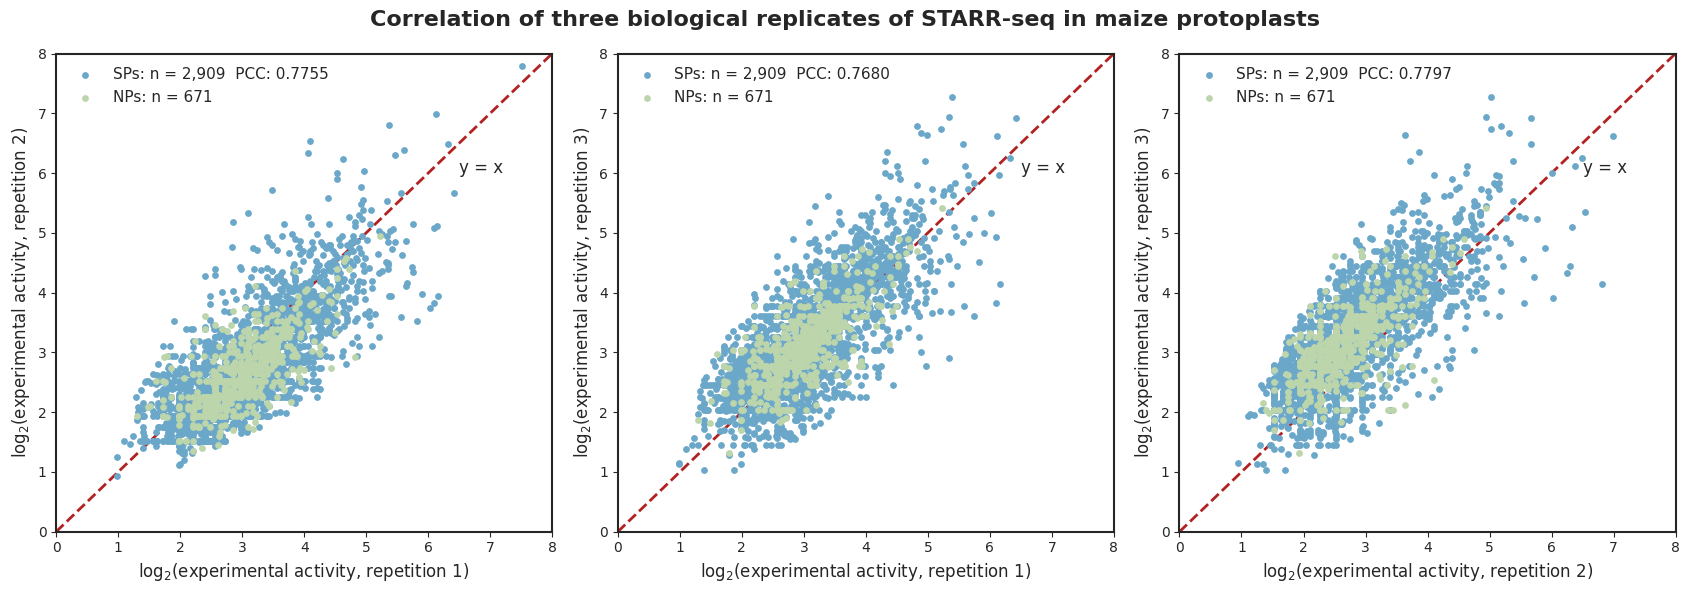

In [ ]:
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
import numpy as np

# 1. Calculate stats (counts are constant across plots as per example)
n_sps = SPs_df.shape[0]
n_nps = NPs_df.shape[0]

# Set up the figure size and subplots
fig, axes = plt.subplots(1, 3, figsize=(17, 6))

# Define the columns for the three replicates
col_rep1 = 'log2(experimental activity, repetition 1)'
col_rep2 = 'log2(experimental activity, repetition 2)'
col_rep3 = 'log2(experimental activity, repetition 3)'

# Define the pairs to plot: (x_column, y_column)
pairs = [
    (col_rep1, col_rep2),
    (col_rep1, col_rep3),
    (col_rep2, col_rep3)
]

lims = [0, 8]

# Helper function to plot each scatter
for ax, (x_col, y_col) in zip(axes, pairs):
    pcc_sp, _ = pearsonr(last_df[x_col], last_df[y_col])
    
    # Plot y=x diagonal line (zorder=1, bottom)
    ax.plot(lims, lims, color='firebrick', linestyle='--', linewidth=2, zorder=1)
    ax.text(6.5, 6, 'y = x', fontsize=12)
    
    # Plot SPs (zorder=2, middle)
    ax.scatter(SPs_df[x_col], SPs_df[y_col], 
               s=15, c='#6ba7c9', 
               label=f'SPs: n = {n_sps:,}  PCC: {pcc_sp:.4f}', 
               zorder=2)
    
    # Plot NPs (zorder=3, top)
    ax.scatter(NPs_df[x_col], NPs_df[y_col], 
               s=15, c='#bcd5ab', 
               label=f'NPs: n = {n_nps:,}', 
               zorder=3)
    
    # Map column names to LaTeX format for labels
    xlabel = x_col.replace('log2', r'$\log_2$')
    ylabel = y_col.replace('log2', r'$\log_2$')
    
    # Set axis limits and labels
    ax.set_xlim(lims)
    ax.set_ylim(lims)
    ax.set_xlabel(xlabel, fontsize=12)
    ax.set_ylabel(ylabel, fontsize=12)
    
    # Set spines linewidth
    for spine in ax.spines.values():
        spine.set_linewidth(1.5)
    
    # Add legend
    ax.legend(loc='upper left', frameon=False, fontsize=11)

# Set the overall title
fig.suptitle('Correlation of three biological replicates of STARR-seq in maize protoplasts', fontsize=16, fontweight='bold')

plt.tight_layout()
plt.show()

### 7.2 Correlation between Predicted and Experimental Activity of SPs

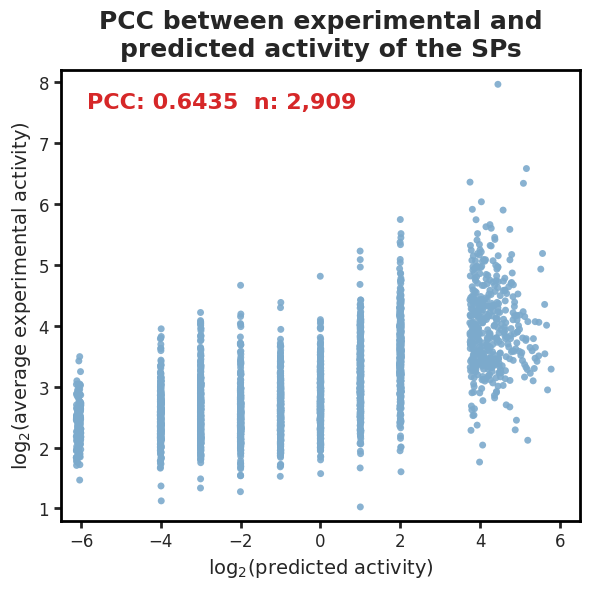

In [139]:
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
import numpy as np


# Prepare data
x_col = 'log2(predicted_activity)'
y_col = 'log2(activity_avg)'
clean_data = SPs_df[[x_col, y_col]].dropna()
x = clean_data[x_col]
y = clean_data[y_col]

# Calculate Statistics
pcc, _ = pearsonr(x, y)
n_count = len(clean_data)

# Setup Figure
fig, ax = plt.subplots(figsize=(6, 6))

# Scatter Plot
# Using a color similar to the reference image
ax.scatter(x, y, color='#7CAACC', s=25, alpha=0.9, edgecolors='none')

# Add Annotation Text (Red, Top Left)
stats_text = f'PCC: {pcc:.4f}  n: {n_count:,}'
ax.text(0.05, 0.95, stats_text, transform=ax.transAxes, 
        fontsize=16, fontweight='bold', color='#D62728', verticalalignment='top')

# Labels and Title
ax.set_xlabel(r'log$_2$(predicted activity)', fontsize=14)
ax.set_ylabel(r'log$_2$(average experimental activity)', fontsize=14)
ax.set_title('PCC between experimental and\npredicted activity of the SPs', fontsize=18, fontweight='bold', pad=10)

# Set Axis Limits and Ticks
ax.set_xlim(-6.5, 6.5)
ax.set_ylim(0.8, 8.2)

# Customize Spines (Thicker borders)
for spine in ax.spines.values():
    spine.set_linewidth(2)
    spine.set_color('black')

# Tick Parameters
ax.tick_params(axis='both', which='major', labelsize=12, width=2, length=5, direction='out')

plt.tight_layout()
plt.show()

### 7.3 Comparison of Natural Promoter Activities Measured in This Study and Those Reported by Jores et al.

findfont: Font family ['Arial'] not found. Falling back to DejaVu Sans.


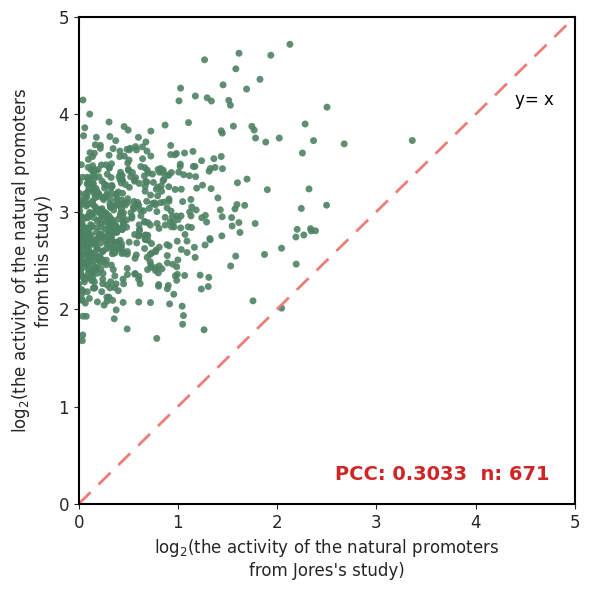

In [ ]:
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
import pandas as pd
import numpy as np

# Load Jores et al. data
# Reading from the relative path based on workspace structure
natural_df = pd.read_excel('../data/Natural_promoters.xlsx')

# 1. Re-extract NPs_df from the original last_df to ensure it is clean and does not contain previous merge results.
NPs_df = last_df[last_df.index.str.startswith('NP')].copy()

# 2. Merge to get enrichment values corresponding to NPs
# We perform an inner merge to find common sequences
plot_df = NPs_df.merge(natural_df[['sequence', 'enrichment']], on='sequence')

# Prepare X (Jores) and Y (This Study)
x_col = 'enrichment'
y_col = 'log2(activity_avg)'
clean_data = plot_df[[x_col, y_col]].dropna()
x = clean_data[x_col]
y = clean_data[y_col]

# Calculate PCC
pcc, _ = pearsonr(x, y)
n_count = len(clean_data)

# Setup Figure
fig, ax = plt.subplots(figsize=(6, 6))

# Scatter Plot
# Dark green color similar to the provided image
ax.scatter(x, y, color='#4E8264', s=25, alpha=0.9, edgecolors='none')

# Diagonal line y=x (dashed, pinkish-red)
ax.plot([0, 5], [0, 5], color='#EA7E79', linestyle='--', linewidth=2, dashes=(6, 4))
ax.text(4.4, 4.1, r'y= x', fontsize=12, color='black')

# Add Annotation Text (Red, Bottom Right)
stats_text = f'PCC: {pcc:.4f}  n: {n_count}'
ax.text(0.95, 0.05, stats_text, transform=ax.transAxes, 
        fontsize=14, fontweight='bold', color='#CE2626', horizontalalignment='right')

# Labels and Title
ax.set_xlabel(r'log$_2$(the activity of the natural promoters' + '\n' + r"from Jores's study)", fontsize=12)
ax.set_ylabel(r'log$_2$(the activity of the natural promoters' + '\n' + r'from this study)', fontsize=12)

# Set Axis Limits
ax.set_xlim(0, 5)
ax.set_ylim(0, 5)

# Customize Spines (Thicker borders)
for spine in ax.spines.values():
    spine.set_linewidth(1.5)
    spine.set_color('black')

# Tick Parameters
ax.tick_params(axis='both', which='major', labelsize=12)

plt.tight_layout()
plt.show()

### 7.4 Distribution of SP Activity across Different Targets

成功加载本地字体: /home/xlxiang/miniconda3/ARIAL.TTF


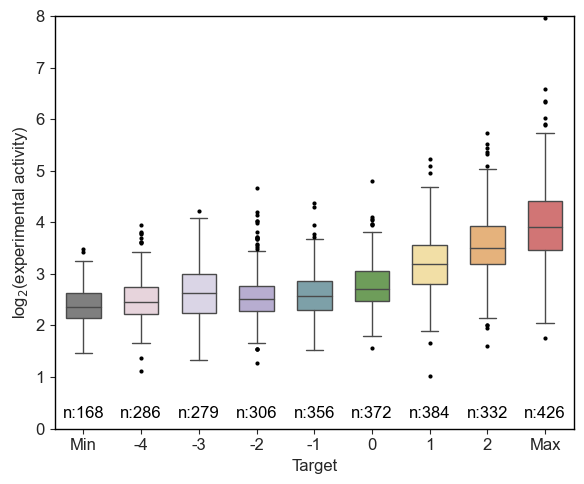

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import matplotlib.font_manager as fm
import os

# --- Fix Arial Font Issue ---
# Load Arial font using the absolute path provided by the user
font_path = '/home/xlxiang/miniconda3/ARIAL.TTF'
if os.path.exists(font_path):
    # Load local font
    fm.fontManager.addfont(font_path)
    plt.rcParams['font.family'] = 'Arial'
    print(f"Successfully loaded local font: {font_path}")
else:
    # Try using system Arial (if installed)
    print(f"'{font_path}' not found in current directory, trying system font configuration...")
    plt.rcParams['font.sans-serif'] = ['Arial', 'DejaVu Sans']

# Set general plotting parameters
plt.rcParams['font.size'] = 12  # Global font size set to 12
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42
plt.rcParams['axes.unicode_minus'] = False # Fix minus sign display issue

# 1. Prepare Data
# Re-extract SPs_df from the original last_df to ensure data purity
SPs_df_clean = last_df[last_df.index.str.startswith('SP')].copy()

# Read TargetGAN data
target_seq = pd.read_excel('/home/xlxiang/TargetGAN-main/data/targetgan_55296.xlsx')

# Merge data
plot_data = SPs_df_clean.merge(target_seq[['sequence', 'target']], on='sequence')
plot_data.rename(columns={'log2(activity_avg)': 'Experimental Activity'}, inplace=True)

# Define order
order = ['min', -4, -3, -2, -1, 0, 1, 2, 'max']

# Custom color palette
custom_palette = {
    'min': '#7F7F7F',   # Grey
    -4: '#EAD1DC',      # Light Pink/Beige
    -3: '#D9D2E9',      # Light Purple
    -2: '#B4A7D6',      # Purple
    -1: '#76A5AF',      # Teal
    0:  '#6AA84F',      # Green
    1:  '#FFE599',      # Yellow
    2:  '#F6B26B',      # Orange
    'max': '#E06666'    # Red
}

# 3. Plotting
plt.figure(figsize=(6, 5))

ax = sns.boxplot(x='target', 
            y='Experimental Activity', 
            data=plot_data, 
            order=order,
            palette=custom_palette,
            width=0.6,
            linewidth=1.0,
            flierprops=dict(marker='o', markersize=3, markerfacecolor='black', markeredgecolor='none'))

# Add N-value annotations
counts = plot_data['target'].value_counts()

for i, label in enumerate(order):
    n_val = counts.get(label, 0)
    # Add text below the boxplot (font size changed to 12)
    ax.text(i, 0.2, f"n:{n_val}", horizontalalignment='center', fontsize=12, color='black')

# Set axis labels (font size changed to 12)
plt.xlabel('Target', fontsize=12) 
plt.ylabel(r'log$_2$(experimental activity)', fontsize=12)

# Set tick labels to Min/Max (capitalized)
new_labels = [str(l).capitalize() if isinstance(l, str) else str(l) for l in order]
ax.set_xticklabels(new_labels, fontsize=12) # Font size changed to 12

# --- Set Y-axis range from 0 to 8 ---
plt.ylim(0, 8)
plt.yticks(range(9), fontsize=12) # Font size changed to 12

# Adjust spines
for spine in ax.spines.values():
    spine.set_linewidth(1.0)
    spine.set_color('black')

plt.tight_layout()
# Save figure
plt.savefig('./data_for_plot/boxplot.svg', dpi=600)
plt.show()

### 7.5 Comparison of Activity Ranges between SPs and NPs

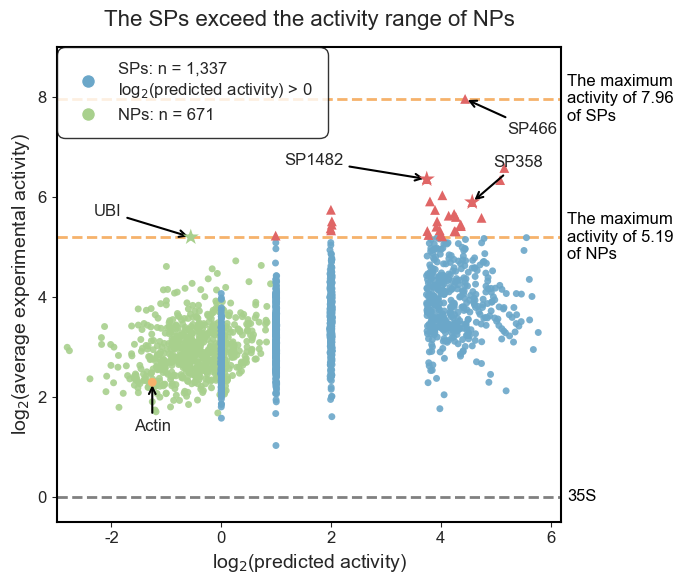

In [190]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.font_manager as fm
from matplotlib.lines import Line2D # Add explicit import

# --- 1. Data Preparation ---

# Filter SPs based on image criteria (log2(predicted activity) > 0)
SPs_filtered = SPs_df[SPs_df['log2(predicted_activity)'] > 0].copy()
NPs_filtered = NPs_df.copy()

# Define thresholds
max_np_activity = 5.19
max_sp_activity = 7.96 # From image text

# Split SPs into "Normal" (<= Max NP) and "High" (> Max NP)
sps_low = SPs_filtered[SPs_filtered['log2(activity_avg)'] <= max_np_activity]
sps_high = SPs_filtered[SPs_filtered['log2(activity_avg)'] > max_np_activity]

# Specific points to highlight
highlight_sps = ['SP1482', 'SP358'] # Stars
highlight_sp_arrow = ['SP466'] # Pointed to
highlight_nps = ['UBI'] # Star
highlight_actin = ['Actin'] # Orange dot

# --- 2. Plotting ---
plt.figure(figsize=(7, 6))
ax = plt.gca()

# 2.1 Base Scatter Plots
# NPs (Green)
plt.scatter(
    NPs_filtered['log2(predicted_activity)'], 
    NPs_filtered['log2(activity_avg)'], 
    s=25, c='#A8D08D', alpha=0.9, edgecolors='none',
    label=f'NPs: n = {len(NPs_filtered):,}'
)

# SPs Low (Blue)
plt.scatter(
    sps_low['log2(predicted_activity)'], 
    sps_low['log2(activity_avg)'], 
    s=25, c='#6BA7C9', alpha=0.9, edgecolors='none',
    label=f'SPs: n = {len(SPs_filtered):,}\nlog$_2$(predicted activity) > 0'
)

# SPs High (Red Triangles)
plt.scatter(
    sps_high['log2(predicted_activity)'], 
    sps_high['log2(activity_avg)'], 
    s=50, c='#E06666', marker='^', alpha=1.0, edgecolors='none'
)

# 2.2 Reference Lines
# 35S Baseline (y=0)
plt.axhline(y=0, color='grey', linestyle='--', linewidth=2, zorder=0)
plt.text(6.3, 0, '35S', va='center', fontsize=12, color='black') # Moved x to 6.3

# Max NP Line (y=5.19)
plt.axhline(y=max_np_activity, color='#F6B26B', linestyle='--', linewidth=2, zorder=0)
plt.text(6.3, max_np_activity, f'The maximum\nactivity of {max_np_activity}\nof NPs', 
         va='center', fontsize=12, color='black', ha='left')

# Max SP Line (y=7.96)
plt.axhline(y=max_sp_activity, color='#F6B26B', linestyle='--', linewidth=2, zorder=0)
plt.text(6.3, max_sp_activity, f'The maximum\nactivity of {max_sp_activity}\nof SPs', 
         va='center', fontsize=12, color='black', ha='left')

# 2.3 Highlights
# UBI (Green Star) - Adjusted position to avoid overlap
ubi_data = NPs_filtered[NPs_filtered['gene'] == 'UBI']
if not ubi_data.empty:
    plt.scatter(ubi_data['log2(predicted_activity)'], ubi_data['log2(activity_avg)'], 
                s=150, c='#A8D08D', marker='*', edgecolors='none', zorder=10)
    plt.annotate('UBI', 
                 xy=(ubi_data['log2(predicted_activity)'].values[0], ubi_data['log2(activity_avg)'].values[0]),
                 xytext=(-50, 15), textcoords='offset points', # Shifted Left & Up
                 arrowprops=dict(arrowstyle='->', color='black', lw=1.5),
                 fontsize=12, fontweight='normal', ha='right')

# Actin (Orange Dot) - Adjusted position
actin_data = NPs_filtered[NPs_filtered['gene'] == 'Actin']
if not actin_data.empty:
    plt.scatter(actin_data['log2(predicted_activity)'], actin_data['log2(activity_avg)'], 
                s=40, c='#F6B26B', marker='o', edgecolors='none', zorder=10)
    plt.annotate('Actin', 
                 xy=(actin_data['log2(predicted_activity)'].values[0], actin_data['log2(activity_avg)'].values[0]),
                 xytext=(0, -35), textcoords='offset points', # Shifted Down
                 arrowprops=dict(arrowstyle='->', color='black', lw=1.5),
                 fontsize=12, fontweight='normal', ha='center')

# SPs Highlights (Red Stars for SP1482, SP358)
for sp_name in highlight_sps:
    if sp_name in SPs_filtered.index:
        sp_data = SPs_filtered.loc[[sp_name]]
    elif 'name1' in SPs_filtered.columns and sp_name in SPs_filtered['name1'].values:
        sp_data = SPs_filtered[SPs_filtered['name1'] == sp_name]
    else:
        continue
        
    plt.scatter(sp_data['log2(predicted_activity)'], sp_data['log2(activity_avg)'], 
                s=150, c='#E06666', marker='*', edgecolors='none', zorder=10)
    
    # Adjusted annotations for SP1482 and SP358 to avoid clutter
    if sp_name == 'SP1482':
        # SP1482: Move Left and slightly Up to clear the vertical band
        offset = (-60, 10) 
        ha = 'right'
    else: # SP358
        # SP358: Move Up and Right to clear cluster
        offset = (15, 25)
        ha = 'left'
    
    plt.annotate(sp_name, 
                 xy=(sp_data['log2(predicted_activity)'].values[0], sp_data['log2(activity_avg)'].values[0]),
                 xytext=offset, textcoords='offset points',
                 arrowprops=dict(arrowstyle='->', color='black', lw=1.5),
                 fontsize=12, ha=ha)

# SP466 (Arrow only to triangle)
if 'SP466' in SPs_filtered.index:
    sp_data = SPs_filtered.loc[['SP466']]
    plt.annotate('SP466', 
                 xy=(sp_data['log2(predicted_activity)'].values[0], sp_data['log2(activity_avg)'].values[0]),
                 xytext=(30, -25), textcoords='offset points', # Shifted Right & Down
                 arrowprops=dict(arrowstyle='->', color='black', lw=1.5),
                 fontsize=12)


# 2.4 Formatting
plt.xlabel(r'log$_2$(predicted activity)', fontsize=14)
plt.ylabel(r'log$_2$(average experimental activity)', fontsize=14)
plt.title('The SPs exceed the activity range of NPs', fontsize=16, fontweight='bold', pad=15)

# Axis limits and ticks
plt.xlim(-3, 6.2) 
plt.ylim(-0.5, 9)

# Spines
for spine in ax.spines.values():
    spine.set_linewidth(1.5)
    spine.set_color('black')

# Legend
legend_elements = [
    Line2D([0], [0], marker='o', color='w', label=f'SPs: n = {len(SPs_filtered):,}\nlog$_2$(predicted activity) > 0',
           markerfacecolor='#6BA7C9', markersize=10),
    Line2D([0], [0], marker='o', color='w', label=f'NPs: n = {len(NPs_filtered):,}',
           markerfacecolor='#A8D08D', markersize=10)
]

leg = plt.legend(handles=legend_elements, loc='upper left', fontsize=12, 
           frameon=True, edgecolor='black', fancybox=True)
leg.get_frame().set_linewidth(1.0)
leg.get_frame().set_boxstyle("Round,pad=0.5")


plt.tight_layout()
plt.show()